## Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

## Load Env Variables

In [2]:
load_dotenv()

True

## Define LLM

In [3]:
model= ChatOpenAI()

## Define State

In [4]:
class QuestionAnswerState(TypedDict):
    question: str
    answer: str
    temp: str

## Define Node

In [ ]:
def question_answer_node(state: QuestionAnswerState) -> QuestionAnswerState:
    question = state["question"]
    prompt= f"Answer the following question: {question}. If it is not a question or any offensive been asked reject the response by say 'It is not a question.'"
    openai_response = model.invoke(prompt)
    answer = openai_response.content
    state["answer"] = answer
    state["temp"] = answer
    return state

def refine_answer(state: QuestionAnswerState) -> QuestionAnswerState:
       answer= state["answer"]
       if answer == 'It is not a question.':
        return state 
       else: 
        prompt2=f"Refine the text in a simple english conclude it upto max 30 words. Here's the text {answer}"
        refine_answer= model.invoke(prompt2).content
        state["answer"]= refine_answer
       return state

## Create Graph

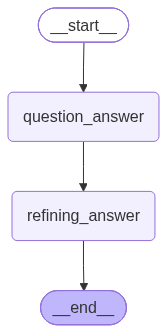

In [6]:
#call graph
graph = StateGraph(QuestionAnswerState)

##Add Nodes
graph.add_node('question_answer', question_answer_node)
graph.add_node('refining_answer', refine_answer)

##Add Edges
graph.add_edge(START,'question_answer')
graph.add_edge('question_answer','refining_answer')
graph.add_edge('refining_answer',END)

workflow= graph.compile()
workflow

## Invoke the graph

In [7]:
initial_state={"question": "Who is a creator of python?"}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

Guido van Rossum is Python's creator, developing the programming language to enhance accessibility and efficiency for users.
